
# Clinical Text Classification Model
**Objective:** To classify medical transcriptions into distinct biological systems using Natural Language Processing (NLP) and Logistic Regression.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional-looking graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.




## Step 1: Exploratory Data Analysis (EDA)
Before training the model, we must understand the raw dataset. We will load the data processed by the `scispacy` pipeline and visualize the distribution of medical specialties to identify any structural imbalances.

Loading preprocessed dataset...


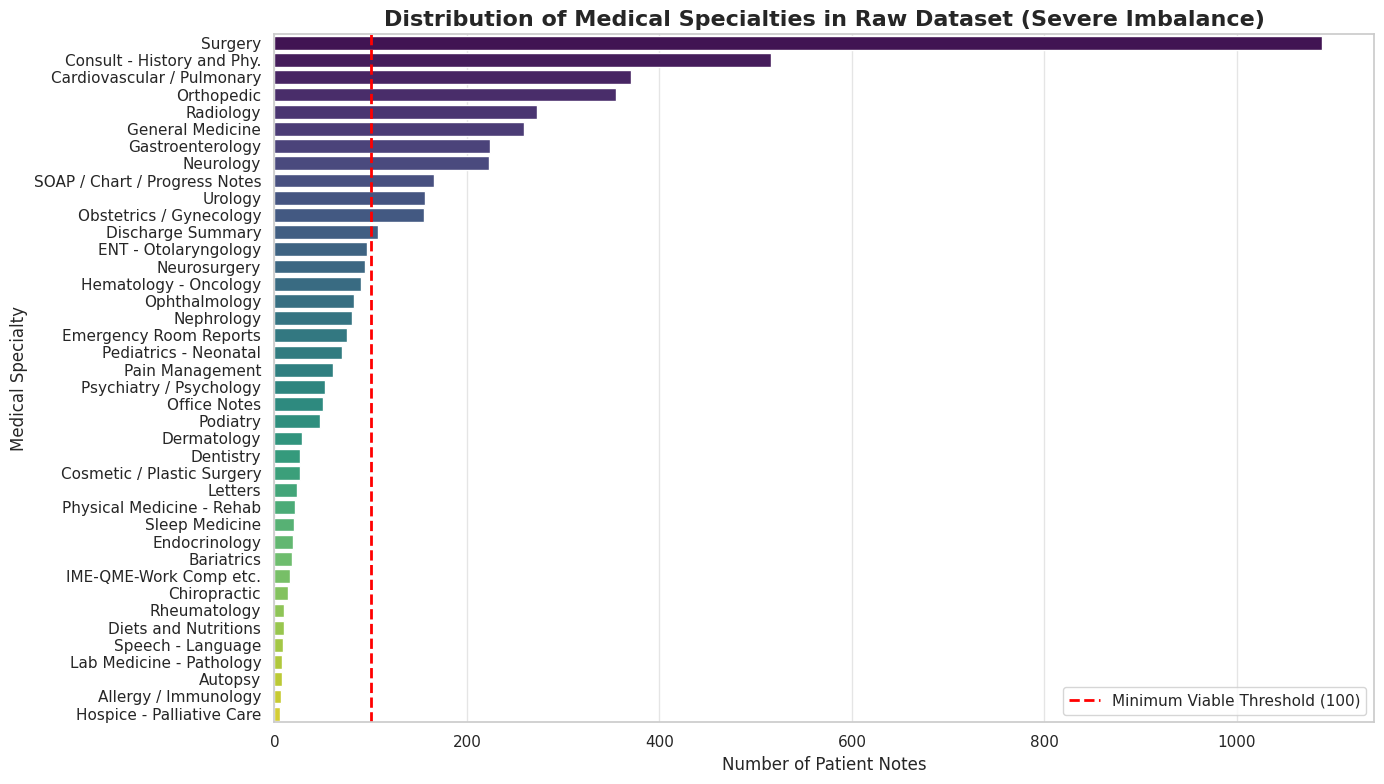

Total Unique Categories: 40


In [2]:
# 1. Load the dataset
print("Loading preprocessed dataset...")
df = pd.read_csv("processed_clinical_data.csv")

# Drop any rows completely missing their target labels
df = df.dropna(subset=['extracted_features', 'medical_specialty'])
df['medical_specialty'] = df['medical_specialty'].str.strip()

# 2. Plot the class distribution
plt.figure(figsize=(14, 8))
class_counts = df['medical_specialty'].value_counts()

# Create a bar chart showing all categories
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis", hue=class_counts.index, legend=False)
plt.title("Distribution of Medical Specialties in Raw Dataset (Severe Imbalance)", fontsize=16, fontweight='bold')
plt.xlabel("Number of Patient Notes", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)

# Add a vertical red line at x=100 to show our "mathematical validity" threshold visually
plt.axvline(x=100, color='red', linestyle='--', linewidth=2, label='Minimum Viable Threshold (100)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total Unique Categories: {len(class_counts)}")

## Step 2: Data Preprocessing and Biological Filtering
As shown in the graph above, the dataset suffers from severe class imbalance. Categories like "Surgery" have over 1,000 samples, while "Allergy / Immunology" has fewer than 10.

Furthermore, many of these categories are administrative hospital billing codes rather than distinct biological systems, leading to extreme vocabulary overlap (e.g., Surgery vs. Orthopedics).

Following the methodology established in our Literature Review, we will filter this dataset down to four distinct biological systems: **Cardiovascular, Neurology, Obstetrics / Gynecology, and Gastroenterology**.

In [3]:
# 1. Define our target biological systems
target_classes = [
    'Cardiovascular / Pulmonary',
    'Neurology',
    'Obstetrics / Gynecology',
    'Gastroenterology'
]

# 2. Filter the dataframe
df_filtered = df[df['medical_specialty'].isin(target_classes)].copy()

# 3. Clean the feature strings for the vectorizer
df_filtered['clean_features'] = df_filtered['extracted_features'].str.replace(r"[\[\]',]", "", regex=True)

# 4. Show the new, clean distribution
print("\n--- Filtered Dataset Ready for Training ---")
print(df_filtered['medical_specialty'].value_counts())
print(f"\nTotal patient notes remaining: {len(df_filtered)}")


--- Filtered Dataset Ready for Training ---
medical_specialty
Cardiovascular / Pulmonary    371
Gastroenterology              224
Neurology                     223
Obstetrics / Gynecology       155
Name: count, dtype: int64

Total patient notes remaining: 973


## Step 3: Feature Extraction (TF-IDF Normalization)
We use **Term Frequency-Inverse Document Frequency (TF-IDF)** to convert our medical codes into a mathematical space.

Unlike standard word counts, TF-IDF inherently normalizes the data. It mathematically penalizes codes that appear in every single document (like a generic code for "patient") and boosts the weight of rare, highly specific codes (like a specific code for "ventricular fibrillation"). Furthermore, `scikit-learn` applies L2 normalization by default, ensuring that longer medical notes do not artificially overpower shorter ones simply because they have more words.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Transforming medical features into TF-IDF vectors...")

# Initialize the vectorizer
vectorizer = TfidfVectorizer()

# X represents our inputs (the vectors)
X = vectorizer.fit_transform(df_filtered['clean_features'])

# y represents our targets (the biological system labels)
y = df_filtered['medical_specialty']

print(f"Matrix Shape: {X.shape}")
print(f"(Rows = {X.shape[0]} patient notes, Columns = {X.shape[1]} unique medical codes)")

Transforming medical features into TF-IDF vectors...
Matrix Shape: (973, 10415)
(Rows = 973 patient notes, Columns = 10415 unique medical codes)


## Step 4: Robust Validation and Hyperparameter Tuning
A simple 80/20 train/test split is not efficient and highly susceptible to luck (all difficult anomalies might end up in the test set). To rigorously evaluate our model, we implement **K-Fold Cross-Validation** via `GridSearchCV`.

The dataset is partitioned into 5 folds. The model trains on 4 folds and tests on the 5th, rotating until every fold has been the test set. Simultaneously, we test multiple internal hyperparameters (like the `C` regularization penalty) to find the mathematically optimal configuration without overfitting.

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
import time

# 1. Split the data.
# We use stratify=y to ensure the 80/20 split maintains the exact same ratio of Heart/Brain/Digestive/Reproductive notes in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Define the exact parameters we want the algorithm to test
param_grid = {
    'C': [0.1, 1.0, 10.0],                # Regularization strength (prevents overfitting)
    'class_weight': ['balanced', None],   # Tests whether it should manually balance the classes
    'solver': ['lbfgs']                   # The optimization algorithm
}

# 3. Set up the 5-Fold Cross Validation Grid Search
print("Starting 5-Fold Cross-Validation and Hyperparameter Tuning...")
start_time = time.time()

# n_jobs=-1 tells your WSL system to use all available CPU cores to speed this up
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Run the engine
grid_search.fit(X_train, y_train)
end_time = time.time()

print(f"Training Complete in {end_time - start_time:.2f} seconds!")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

Starting 5-Fold Cross-Validation and Hyperparameter Tuning...
Training Complete in 42.30 seconds!
Best Hyperparameters Found: {'C': 10.0, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 86.63%


Evaluating the optimal model on the hidden test set...

=== FINAL CLASSIFICATION REPORT ===
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.84      0.91      0.87        74
          Gastroenterology       0.86      0.82      0.84        45
                 Neurology       0.92      0.98      0.95        45
   Obstetrics / Gynecology       0.96      0.74      0.84        31

                  accuracy                           0.88       195
                 macro avg       0.89      0.86      0.87       195
              weighted avg       0.88      0.88      0.88       195



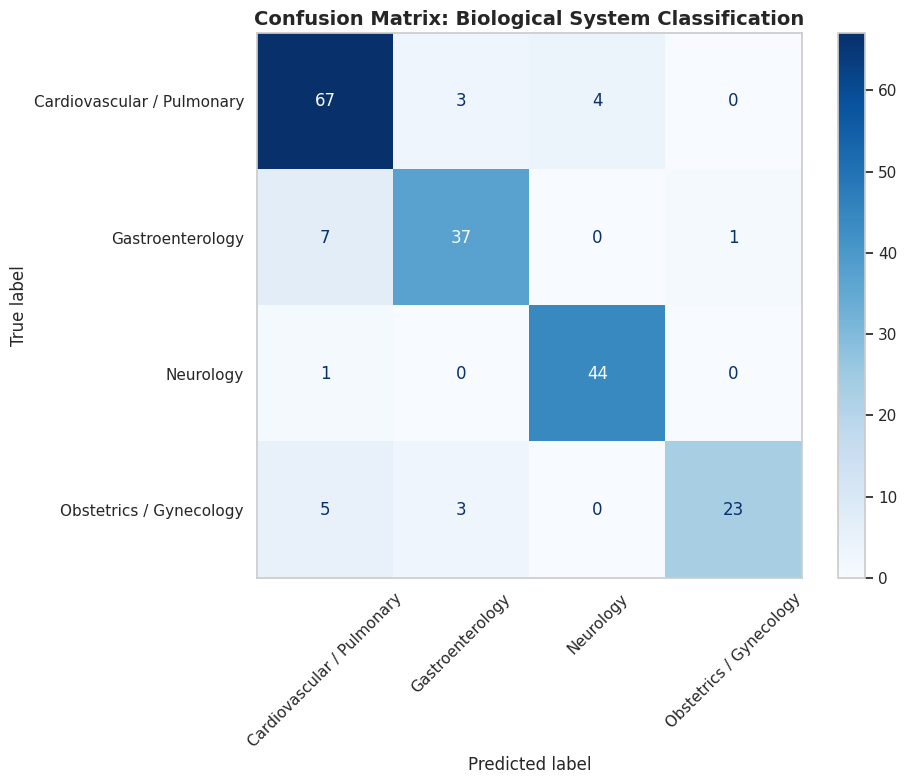

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Grab the winning model from our Grid Search
best_model = grid_search.best_estimator_

# 2. Make final predictions on the 20% test set
print("Evaluating the optimal model on the hidden test set...\n")
y_pred = best_model.predict(X_test)

# 3. Print the text report
print("=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, zero_division=0))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

plt.figure(figsize=(10, 8))
# We use a blue color map to keep it professional for the report
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())

plt.title("Confusion Matrix: Biological System Classification", fontsize=14, fontweight='bold')
plt.grid(False) # Turn off the seaborn grid lines for this specific chart
plt.tight_layout()
plt.show()